<a href="https://colab.research.google.com/github/dionysus-laughed/school_cs4410/blob/main/summers_hw5_cs4410.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_iris, fetch_openml
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Set plot style for Colab
plt.rcParams['figure.figsize'] = [10, 6]

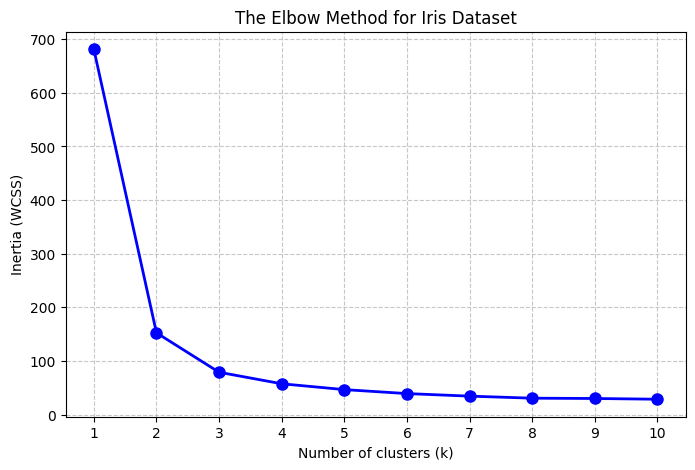

In [ ]:
# Load Iris data
iris = load_iris()
X_iris = iris.data

wcss = []
k_range = range(1, 11)

# Iterate through possible k values
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_iris)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', markersize=8, linewidth=2)
plt.title('The Elbow Method for Iris Dataset')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Fetching MNIST dataset... (This will take a bit.)")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

# Split data into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (Mean = 0, Variance = 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Data loaded and scaled. Training set size: {X_train.shape[0]}")

Fetching MNIST dataset... (This will take a bit.)
Data loaded and scaled. Training set size: 49000


In [ ]:
print("Training Logistic Regression on full 784 features...")
start_time = time.time()

# We use a higher max_iter to ensure convergence on the full dataset
logisticRegr = LogisticRegression(solver='lbfgs', max_iter=500)
logisticRegr.fit(X_train, y_train)

time_no_pca = time.time() - start_time
score_no_pca = logisticRegr.score(X_test, y_test)

print(f"Done! Time: {time_no_pca:.2f}s | Accuracy: {score_no_pca:.4f}")

Training Logistic Regression on full 784 features...
Done! Time: 68.41s | Accuracy: 0.9137


In [ ]:
# Apply PCA to keep 95% of the variance
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Reduced features from 784 down to {pca.n_components_}")

print("Training Logistic Regression on PCA-reduced features...")
start_time = time.time()

logisticRegr_pca = LogisticRegression(solver='lbfgs', max_iter=500)
logisticRegr_pca.fit(X_train_pca, y_train)

time_pca = time.time() - start_time
score_pca = logisticRegr_pca.score(X_test_pca, y_test)

print(f"Done. Time: {time_pca:.2f}s | Accuracy: {score_pca:.4f}")

Reduced features from 784 down to 327
Training Logistic Regression on PCA-reduced features...
Done. Time: 71.60s | Accuracy: 0.9222


In [ ]:
#Comparison
print("\n" + "="*45)
print("FINAL PERFORMANCE COMPARISON")
print("="*45)
print(f"{'Metric':<20} | {'Full (784)':<12} | {'PCA ('+str(pca.n_components_)+')'}")
print("-" * 45)
print(f"{'Training Time (s)':<20} | {time_no_pca:<12.2f} | {time_pca:.2f}")
print(f"{'Accuracy Score':<20} | {score_no_pca:<12.4f} | {score_pca:.4f}")
print("-" * 45)

speedup = time_no_pca / time_pca
print(f"PCA was {speedup:.1f}x faster than the full model.")


FINAL PERFORMANCE COMPARISON
Metric               | Full (784)   | PCA (327)
---------------------------------------------
Training Time (s)    | 68.41        | 71.60
Accuracy Score       | 0.9137       | 0.9222
---------------------------------------------
PCA was 1.0x faster than the full model.
